In [104]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib import pyplot as plt

To initiate our analysis, we recreate and re-fit our top-performing model from the exploratory phase: the Per Capita Specification. This provides the baseline object needed to run formal residual, normality, and autocorrelation diagnostics

In [105]:
df = pd.read_csv('data/processed/beef_market_clean_dataset.csv')

X = pd.DataFrame(
    {
        'const': 1,
        'imports_per_capita': (df['imports'] / df['population'])*1000,
        'exports_per_capita': (df['exports'] / df['population'])*1000,
        'production_per_capita': (df['total_production'] / df['population'])*1000
    }
)

cur_cpi = df.loc[df['year'] == 2025]['PPIACO'].squeeze()
df['select_price_real_2025'] = df['select_price'] * (cur_cpi/df['PPIACO'])

y = df['select_price_real_2025']

model = sm.OLS(y, X).fit()

To evaluate the independent stability of each predictor, we compute the Variance Inflation Factor (VIF). The VIF measures the degree to which the variance of an estimated regression coefficient is inflated due to collinearity with other features in the model; severe collinearity inflates standard errors, rendering the model unstable. A VIF of 1.0 indicates an absence of collinearity. Every predictor in our per capita model yields a VIF bounded between 1.00 and 1.07, indicating that multicollinearity is negligible and our coefficient estimates are structurally stable.

In [106]:
df_vif = pd.DataFrame()
df_vif['Features'] = X.columns
df_vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(df_vif)

                Features         VIF
0                  const  341.423371
1     imports_per_capita    1.067185
2     exports_per_capita    1.063322
3  production_per_capita    1.014990


Next, we will examine the extent to which serial correlation in the residuals affects the validity of the model. If there is correlation among the error terms, the standard errors will be underestimated and confidence in the model's significance will be higher than warranted. The residuals should appear random when plotted if there is no correlation. However, we know from our initial analysis that the Durbin-Watson score of 1.5358 suggests some degree of serial correlation.

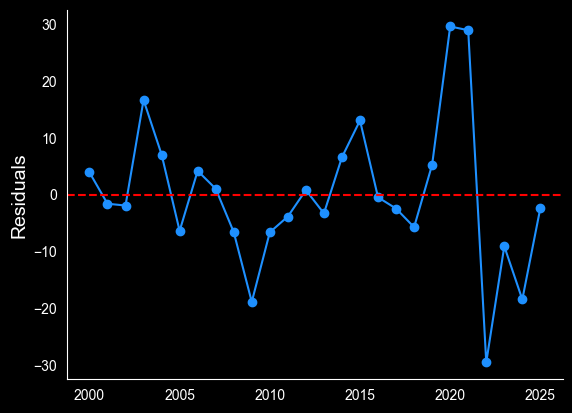

In [107]:
preds = model.predict(X)
residuals = y - preds

year = df['year']

fig, ax = plt.subplots()

ax.scatter(year, residuals, color='dodgerblue')
ax.plot(year, residuals, color='dodgerblue')
ax.axhline(0, color='red', linestyle='--')

ax.set_ylabel('Residuals', fontsize=14)
ax.grid(visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


We can see from the plot above that adjacent residuals exhibit similar values over time, visually confirming the violation of the OLS assumption of uncorrelated error terms. Next, we will evaluate the model for the presence of heteroskedasticity (non-constant variance in the errors). Because classical OLS assumes homoskedasticity—meaning error terms must maintain a constant variance ($\sigma^2$) across all observations—we will fit a Locally Weighted Scatterplot Smoothing (LOWESS) curve. By fitting a series of localized regressions across a rolling proportion of our data, the LOWESS curve will help us visually identify any systematic trends or shifting spreads in our residual volatility

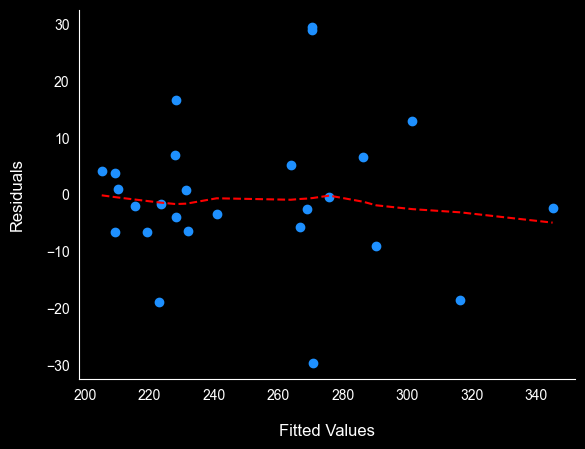

In [91]:
fig, ax = plt.subplots()

# plot residuals against fitted values
ax.scatter(preds, residuals, color='dodgerblue')

ax.set_xlabel('Fitted Values', fontsize=12, labelpad=15)
ax.set_ylabel('Residuals', fontsize=12, labelpad=15)
# fit a LOWESS smoothing curve using 60% of observations to estimate local trend
smoothed = lowess(residuals, preds, frac=0.6)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linestyle='--')

ax.grid(visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

The LOWESS curve remains mostly flat, though slightly negative. Another way to detect potential heteroskedasticity from this plot is by looking for a funnel shape, where the magnitude of the residuals increases systematically. We can see that there is an increasing spread toward the center of the plot, which then proceeds to narrow again with higher fitted values.

Next, we will introduce a robust covariance estimator to calculate our standard errors rather than relying on classical OLS assumptions. To do so, we will set the cov_type to 'HAC' (Heteroskedasticity and Autocorrelation Consistent), which explicitly considers error terms from previous periods. We will fit and evaluate new models testing lag values of 1, 2, and 3 years

In [64]:
model_hac_lag1 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':1})
model_hac_lag2 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':2})
model_hac_lag3 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':3})

In [92]:
base_df = model.summary2().tables[1][['Std.Err.']]
print(f'Base model // Probability (F-Statistic): {model.f_pvalue}', '\n', base_df, '\n')
lag1_df = model_hac_lag1.summary2().tables[1][['Std.Err.']]
print(f'Lag q=1 // Probability (F-Statistic): {model_hac_lag1.f_pvalue}', '\n', lag1_df, '\n')
lag2_df = model_hac_lag2.summary2().tables[1][['Std.Err.']]
print(f'Lag q=2 // Probability (F-Statistic): {model_hac_lag2.f_pvalue}', '\n', lag2_df, '\n')
lag3_df = model_hac_lag3.summary2().tables[1][['Std.Err.']]
print(f'Lag q=3 // Probability (F-Statistic): {model_hac_lag3.f_pvalue}', '\n', lag3_df, '\n')

Base model // Probability (F-Statistic): 8.593449297149384e-11 
                         Std.Err.
const                  49.905182
imports_per_capita      1.368843
exports_per_capita      1.271040
production_per_capita   0.524517 

Lag q=1 // Probability (F-Statistic): 7.43264246895993e-13 
                         Std.Err.
const                  28.505268
imports_per_capita      1.017804
exports_per_capita      1.132345
production_per_capita   0.316401 

Lag q=2 // Probability (F-Statistic): 8.505522441964077e-13 
                         Std.Err.
const                  27.687107
imports_per_capita      1.113220
exports_per_capita      1.088251
production_per_capita   0.308349 

Lag q=3 // Probability (F-Statistic): 9.342133377808363e-13 
                         Std.Err.
const                  28.009304
imports_per_capita      1.140853
exports_per_capita      0.977654
production_per_capita   0.312895 



From the results of the new models, we can see that the standard errors for each of the predictors remain stable, meaning our robust error estimation is not highly sensitive to the exact choice of lag length. Production per capita is the most stable, with the standard error for imports per capita increasing slightly and the standard error for exports decreasing slightly. The lag specifications appear to have a smoothing effect on exports per capita, while the slight increase in the standard errors for imports indicates that price effects related to imports have a longer-run dependence.

Interestingly, all of the HAC standard errors have decreased slightly from the baseline model, meaning the default OLS variance estimate was actually somewhat conservative, or that there is an underlying negative serial correlation component. Lastly, we will plot the correlations as a function of the lag values to inspect this behavior.

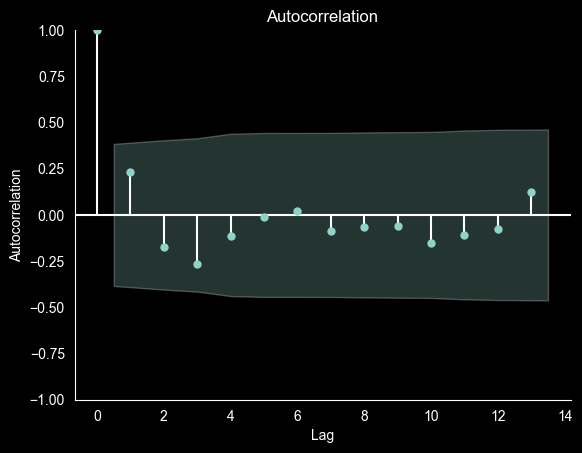

In [97]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots()
plot_acf(residuals, ax=ax)

ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

The ACF plot verifies the presence of a slight negative autocorrelation at our initial lags, providing empirical justification for why our HAC standard errors were marginally reduced relative to the baseline OLS estimates. The plot also confirms that this autocorrelation is relatively weak; every lag coefficient falls well within the 95% confidence interval bounds, indicating that any residual serial dependency is statistically insignificant and structurally equivalent to white noise.

With these diagnostics complete, we have successfully demonstrated that our per capita supply model is robust to multicollinearity among the predictors, serial correlation of the error terms, and heteroskedasticity.

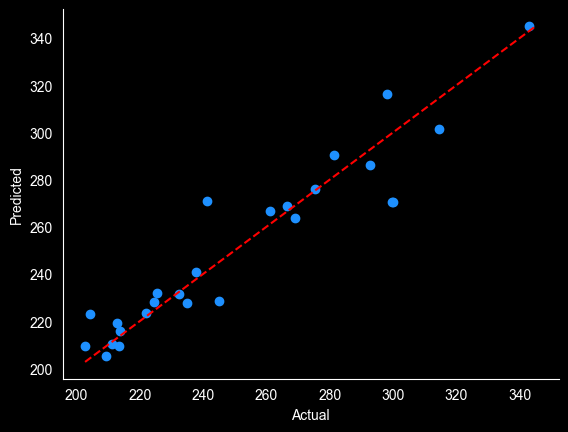

In [103]:
fig, ax = plt.subplots()

ax.scatter(y, preds, color='dodgerblue')
min_val = min(y.min(), preds.min())
max_val = max(y.max(), preds.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    color='red'
)

ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.grid(visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

**Conclusion**

A visual comparison of our model’s predictions against actual historical observations demonstrates strong alignment: points tracking the 45-degree line indicate near-perfect predictions, while deviations highlight periods of localized under- and over-prediction. Backed by a robust Adjusted $R^2$ of 0.892 and verified against classical linear regression assumptions, this framework provides a statistically sound tool for analyzing the mechanics of real wholesale beef prices. Our parameter estimates yield highly revealing structural insights:

**Production & Exports**: Aligned with fundamental supply and demand principles, production per capita exerts a downward pressure on price ($\beta = -5.0631$), while exports per capita reduce domestic supply, driving wholesale prices up ($\beta = 7.6534$).

**The Import Paradox**: Unexpectedly, imports per capita yield a strong positive coefficient ($\beta = 9.2800$), suggesting that expanding import volumes coincide with rising prices. Rather than violating economic logic, this positive import coefficient highlights a compelling avenue for future research. It suggests that imports are likely endogenously tied to broader macro drivers—such as shifting domestic herd cycles, rising energy and agricultural input costs, or supply shortfalls—that pull in foreign beef while simultaneously driving prices upward.

Ultimately, this baseline model sets the stage for a deeper exploration into how these overlapping global and domestic pressures shape the modern beef supply chain.